## Exploratory Data Analysis (EDA) on Sales Data

### Scenario
GlobalMart, a large international retail chain. The company wants to understand its sales performance across different regions, product categories, and time periods. Your task is to perform an exploratory data analysis on the company's sales data to uncover insights that can drive business decisions.

### Your Mission
Conduct an exploratory data analysis on GlobalMart's sales data using Python. You'll need to import the data, clean it, perform basic analyses, and create visualizations to communicate your findings.

### The Data
The dataset is "Global Superstore Dataset". This dataset contains information about sales, profits, product categories, customer segments, and geographical data.

Dataset: Global_Superstore.csv

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### Load Dataset

In [63]:
df = pd.read_csv('Global_Superstore.csv')

In [64]:
df.shape

(1000, 24)

In [ ]:
# Show ALL columns
pd.set_option('display.max_columns', None)

In [66]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Postal Code,City,State,Country,Region,Market,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,40098,CA-2014-AB10015140-41954,11/11/2014,11/13/2014,First Class,AB-100151402,Aaron Bergman,Consumer,73120.0,Oklahoma City,Oklahoma,United States,Central US,USCA,TEC-PH-5816,Technology,Phones,Samsung Convoy 3,221.98,2,0.0,62.15,40.77,High
1,26341,IN-2014-JR162107-41675,2/5/2014,2/7/2014,Second Class,JR-162107,Justin Ritter,Corporate,NaN,Wollongong,New South Wales,Australia,Oceania,Asia Pacific,FUR-CH-5379,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.40,9,0.1,-288.77,923.63,Critical
2,25330,IN-2014-CR127307-41929,10/17/2014,10/18/2014,First Class,CR-127307,Craig Reiter,Consumer,NaN,Brisbane,Queensland,Australia,Oceania,Asia Pacific,TEC-PH-5356,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.17,9,0.1,919.97,915.49,Medium
3,13524,ES-2014-KM1637548-41667,1/28/2014,1/30/2014,First Class,KM-1637548,Katherine Murray,Home Office,NaN,Berlin,Berlin,Germany,Western Europe,Europe,TEC-PH-5267,Technology,Phones,"Motorola Smart Phone, Cordless",2892.51,5,0.1,-96.54,910.16,Medium
4,47221,SG-2014-RH9495111-41948,11/5/2014,11/6/2014,Same Day,RH-9495111,Rick Hansen,Consumer,NaN,Dakar,Dakar,Senegal,Western Africa,Africa,TEC-CO-6011,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.96,8,0.0,311.52,903.04,Critical


In [67]:
df.sample(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Postal Code,City,State,Country,Region,Market,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
568,33399,CA-2012-AH10120140-41107,7/17/2012,7/17/2012,Same Day,AH-101201404,Adrian Hane,Home Office,85705.0,Tucson,Arizona,United States,Western US,USCA,FUR-CH-5428,Furniture,Chairs,Office Star - Ergonomically Designed Knee Chair,259.14,4,0.2,-25.91,31.150,High
739,14209,ES-2015-HD1478548-42271,9/24/2015,10/1/2015,Standard Class,HD-1478548,Harold Dahlen,Home Office,NaN,Schwerin,Mecklenburg-Vorpommern,Germany,Western Europe,Europe,FUR-BO-3903,Furniture,Bookcases,"Dania Library with Doors, Pine",1964.25,6,0.1,21.69,237.780,Low
28,38460,CA-2012-AH10030140-41020,4/21/2012,4/23/2012,Second Class,AH-100301406,Aaron Hawkins,Corporate,12180.0,Troy,New York,United States,Eastern US,USCA,OFF-FA-6129,Office Supplies,Fasteners,Staples,247.84,8,0.0,121.44,55.200,Critical
600,13059,ES-2013-Dl1360045-41440,6/15/2013,6/15/2013,Same Day,Dl-1360045,Dorris liebe,Corporate,NaN,Mont-de-Marsan,Aquitaine-Limousin-Poitou-Charentes,France,Western Europe,Europe,TEC-AC-5135,Technology,Accessories,"Logitech Router, Erganomic",980.52,4,0.0,176.40,263.710,High
787,10183,US-2014-CR1273018-41993,12/20/2014,12/22/2014,First Class,CR-1273018,Craig Reiter,Consumer,NaN,Indaial,Santa Catarina,Brazil,South America,LATAM,FUR-TA-3420,Furniture,Tables,"Bevis Conference Table, Fully Assembled",740.18,3,0.6,-407.14,231.517,Critical


In [68]:
df.tail(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Postal Code,City,State,Country,Region,Market,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
995,24278,IN-2015-JF1541527-42095,4/1/2015,4/5/2015,Standard Class,JF-1541527,Jennifer Ferguson,Consumer,NaN,Liaoyang,Liaoning,China,Eastern Asia,Asia Pacific,FUR-TA-3442,Furniture,Tables,"Bevis Wood Table, with Bottom Storage",2614.69,7,0.30,-821.96,203.260,Medium
996,36249,CA-2015-AS10225140-42347,12/9/2015,12/13/2015,Second Class,AS-102251404,Alan Schoenberger,Corporate,94109.0,San Francisco,California,United States,Western US,USCA,OFF-AP-3371,Office Supplies,Appliances,Belkin 8-Outlet Premiere SurgeMaster II Surge ...,69.48,1,0.00,20.84,12.040,High
997,30517,IN-2014-CK1259592-41929,10/17/2014,10/19/2014,Second Class,CK-1259592,Clytie Kelty,Consumer,NaN,Taupo,Waikato,New Zealand,Oceania,Asia Pacific,TEC-CO-3689,Technology,Copiers,"Canon Fax Machine, Laser",636.78,2,0.00,286.50,203.200,Critical
998,1408,MX-2014-SS2014018-41658,1/19/2014,1/26/2014,Standard Class,SS-2014018,Saphhira Shifley,Corporate,NaN,Araguaína,Tocantins,Brazil,South America,LATAM,FUR-BO-3627,Furniture,Bookcases,"Bush Classic Bookcase, Traditional",2751.20,10,0.00,110.00,203.132,Medium
999,20944,ID-2015-RP19855130-42348,12/10/2015,12/14/2015,Standard Class,RP-19855130,Roy Phan,Corporate,NaN,Bangkok,Bangkok,Thailand,Southeastern Asia,Asia Pacific,TEC-PH-5355,Technology,Phones,"Nokia Smart Phone, Full Size",1587.00,3,0.17,-76.56,203.080,Medium


#### Data Exploration

In [ ]:
# Enumerate the features/columns
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Postal Code', 'City',
       'State', 'Country', 'Region', 'Market', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit', 'Shipping Cost', 'Order Priority'],
      dtype='object')

In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          1000 non-null   int64  
 1   Order ID        1000 non-null   object 
 2   Order Date      1000 non-null   object 
 3   Ship Date       1000 non-null   object 
 4   Ship Mode       1000 non-null   object 
 5   Customer ID     1000 non-null   object 
 6   Customer Name   1000 non-null   object 
 7   Segment         1000 non-null   object 
 8   Postal Code     194 non-null    float64
 9   City            1000 non-null   object 
 10  State           1000 non-null   object 
 11  Country         1000 non-null   object 
 12  Region          1000 non-null   object 
 13  Market          1000 non-null   object 
 14  Product ID      1000 non-null   object 
 15  Category        1000 non-null   object 
 16  Sub-Category    1000 non-null   object 
 17  Product Name    1000 non-null   ob

In [ ]:
# Enumerate the column types
df.dtypes

Row ID              int64
Order ID           object
Order Date         object
Ship Date          object
Ship Mode          object
Customer ID        object
Customer Name      object
Segment            object
Postal Code       float64
City               object
State              object
Country            object
Region             object
Market             object
Product ID         object
Category           object
Sub-Category       object
Product Name       object
Sales             float64
Quantity            int64
Discount          float64
Profit            float64
Shipping Cost     float64
Order Priority     object
dtype: object

In [72]:
#show the number of cells in the dataframe
print("dataset size: ", df.size)

dataset size:  24000


###  Initial EDA Observations

In [73]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit,Shipping Cost
count,1000.000000,194.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,25079.328000,53966.170103,1710.971470,5.55800,0.092840,288.920440,272.384897
std,12897.726632,33734.306466,1259.239238,2.71846,0.148666,574.504782,176.160716
min,58.000000,2920.000000,1.910000,1.00000,0.000000,-3059.820000,1.070000
25%,15118.750000,19134.000000,826.907500,4.00000,0.000000,10.037500,209.827500
50%,25084.500000,60564.000000,1585.115000,5.00000,0.000000,190.685000,258.897500
75%,34524.000000,88187.500000,2477.812500,7.00000,0.150000,518.872500,351.070250
max,51284.000000,98198.000000,9892.740000,14.00000,0.800000,4946.370000,923.630000


Based on the above result, I can see the following:

- RangeIndex: 1000 entries, 0 to 999
- No missing data except for Postal Code column
- "Postal Code" should be alphanumeric NOT float64. Also NaN values
- Order ID, Customer ID and Product ID are objects. 
- ID fields are ALPHANUMERIC e.g TEC-PH-5356, AB-100151402
- "Ship Date" & "Ship Date" are objects - convert to datetime object
- Customer name is first and last name. Split into first and last name columns
- Profit has negative values ie a LOSS
- Mean (average) values
  - Sales 1710.97
  - Quantity 5.6
  - Profit 288.92
- Max values
  - Sales 9892.74
  - Quantity 14
  - Profit 4946.37

#### Data Cleaning

In [ ]:
# Data Cleaning
#    Check for missing values
#    Handle any missing or inconsistent data
#    Convert data types if necessary (e.g., dates to datetime objects)

In [75]:
col_missing_values = df.isna().sum()
col_missing_values

Row ID              0
Order ID            0
Order Date          0
Ship Date           0
Ship Mode           0
Customer ID         0
Customer Name       0
Segment             0
Postal Code       806
City                0
State               0
Country             0
Region              0
Market              0
Product ID          0
Category            0
Sub-Category        0
Product Name        0
Sales               0
Quantity            0
Discount            0
Profit              0
Shipping Cost       0
Order Priority      0
dtype: int64

In [ ]:
# Drop Postal Code as it has TOO MANY missing values
df.drop('Postal Code', axis=1, inplace=True)


In [ ]:
# Show difference after dropped column
col_missing_values2 = df.isna().sum()
col_missing_values2

Row ID              0
Order ID            0
Order Date          0
Ship Date           0
Ship Mode           0
Customer ID         0
Customer Name       0
Segment             0
Postal Code       806
City                0
State               0
Country             0
Region              0
Market              0
Product ID          0
Category            0
Sub-Category        0
Product Name        0
Sales               0
Quantity            0
Discount            0
Profit              0
Shipping Cost       0
Order Priority      0
dtype: int64

In [79]:
# Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
#        'Customer ID', 'Customer Name', 'Segment', 'Postal Code', 'City',
#        'State', 'Country', 'Region', 'Market', 'Product ID', 'Category',
#        'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
#        'Profit', 'Shipping Cost', 'Order Priority'],
#       dtype='object')

In [ ]:
# Check for emtpty Customer name srings
# No non-visible characters or white space
df['Customer Name'].str.isspace().sum()

np.int64(0)

In [ ]:
# Count Customer ID that are ONLY aphabetic strings
# Customer ID should be alphanumeric
df['Customer ID'].str.isalpha().sum()

np.int64(0)

In [ ]:
# Check for duplicate RowIDs
duplicate_RowID = df[df.duplicated(subset=['Row ID'], keep=False)]
duplicate_RowID 

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,Country,Region,Market,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority


In [83]:
df.duplicated().sum()

np.int64(0)

In [84]:
# columns
# All columsn EXCEPT "Postal Code"
df_columns = ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'City',
       'State', 'Country', 'Region', 'Market', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit', 'Shipping Cost', 'Order Priority']
df.duplicated(subset = df_columns).sum()

np.int64(0)

NO duplicated rows

In [85]:
# Convert 'Order Date', 'Ship Date' to datatime
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          1000 non-null   int64         
 1   Order ID        1000 non-null   object        
 2   Order Date      1000 non-null   datetime64[ns]
 3   Ship Date       1000 non-null   datetime64[ns]
 4   Ship Mode       1000 non-null   object        
 5   Customer ID     1000 non-null   object        
 6   Customer Name   1000 non-null   object        
 7   Segment         1000 non-null   object        
 8   City            1000 non-null   object        
 9   State           1000 non-null   object        
 10  Country         1000 non-null   object        
 11  Region          1000 non-null   object        
 12  Market          1000 non-null   object        
 13  Product ID      1000 non-null   object        
 14  Category        1000 non-null   object        
 15  Sub-C

In [87]:
# Number of unique values in columns
# Ref 2
unique_val_cols = ['Ship Mode', 'Segment',  'Region', 'Market',  'Category','Sub-Category', 'Order Priority']
df[unique_val_cols].nunique()

Ship Mode          4
Segment            3
Region            22
Market             5
Category           3
Sub-Category      17
Order Priority     4
dtype: int64

In [ ]:
# Unique values in columns
# Ref 2
{col: df[col].unique() for col in unique_val_cols}


{'Ship Mode': array(['First Class', 'Second Class', 'Same Day', 'Standard Class'],
       dtype=object),
 'Segment': array(['Consumer', 'Corporate', 'Home Office'], dtype=object),
 'Region': array(['Central US', 'Oceania', 'Western Europe', 'Western Africa',
        'Western US', 'Southern Asia', 'Western Asia', 'South America',
        'Eastern Asia', 'Southern Europe', 'Eastern Africa',
        'Eastern Europe', 'Northern Europe', 'Central America',
        'Eastern US', 'Caribbean', 'Central Africa', 'Southeastern Asia',
        'Southern US', 'North Africa', 'Southern Africa', 'Canada'],
       dtype=object),
 'Market': array(['USCA', 'Asia Pacific', 'Europe', 'Africa', 'LATAM'], dtype=object),
 'Category': array(['Technology', 'Furniture', 'Office Supplies'], dtype=object),
 'Sub-Category': array(['Phones', 'Chairs', 'Copiers', 'Tables', 'Bookcases', 'Art',
        'Appliances', 'Storage', 'Fasteners', 'Machines', 'Accessories',
        'Furnishings', 'Binders', 'Labels', 'Paper',

In [90]:
df['Segment'].unique()

array(['Consumer', 'Corporate', 'Home Office'], dtype=object)

In [91]:
df['Region'].unique()

array(['Central US', 'Oceania', 'Western Europe', 'Western Africa',
       'Western US', 'Southern Asia', 'Western Asia', 'South America',
       'Eastern Asia', 'Southern Europe', 'Eastern Africa',
       'Eastern Europe', 'Northern Europe', 'Central America',
       'Eastern US', 'Caribbean', 'Central Africa', 'Southeastern Asia',
       'Southern US', 'North Africa', 'Southern Africa', 'Canada'],
      dtype=object)

In [92]:
# Basic Analysis

#    Calculate total sales and profit
#    Identify top-selling products
#    Analyze sales by region
#    Examine the relationship between sales and profit

In [93]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()

In [94]:
print(f"Total Sales: {total_sales:.2f}")
print(f"Total Profit: {total_profit:.2f}")


Total Sales: 1710971.47
Total Profit: 288920.44


In [95]:
# Sort by sales
df.sort_values(by=['Sales'], ascending=False).head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,Country,Region,Market,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
419,40336,CA-2014-AB10105140-41991,2014-12-18,2014-12-22,Standard Class,AB-101051402,Adrian Barton,Consumer,Detroit,Michigan,United States,Central US,USCA,OFF-BI-4345,Office Supplies,Binders,GBC Ibimaster 500 Manual ProClick Binding System,9892.74,13,0.0,4946.37,498.70,Medium
17,12069,ES-2015-PJ1883564-42255,2015-09-08,2015-09-14,Standard Class,PJ-1883564,Patrick Jones,Corporate,Prato,Tuscany,Italy,Southern Europe,Europe,OFF-AP-4743,Office Supplies,Appliances,"Hoover Stove, Red",7958.58,14,0.0,3979.08,778.32,Low
215,27720,ID-2012-CA1196566-40949,2012-02-10,2012-02-15,Standard Class,CA-1196566,Carol Adams,Corporate,Fuji,Shizuoka,Japan,Eastern Asia,Asia Pacific,TEC-PH-5841,Technology,Phones,"Samsung Smart Phone, VoIP",6998.64,11,0.0,2939.31,413.80,Medium
641,30958,IN-2014-AS1063092-41989,2014-12-16,2014-12-20,Standard Class,AS-1063092,Ann Steele,Home Office,Whakatane,Bay of Plenty,New Zealand,Oceania,Asia Pacific,TEC-PH-5268,Technology,Phones,"Motorola Smart Phone, Full Size",6439.80,10,0.0,2447.10,255.36,Medium
43,16681,ES-2013-GT14710139-41621,2013-12-13,2013-12-17,Standard Class,GT-14710139,Greg Tran,Consumer,Huddersfield,England,United Kingdom,Northern Europe,Europe,TEC-PH-5267,Technology,Phones,"Motorola Smart Phone, Cordless",5785.02,9,0.0,404.73,656.73,High


In [96]:
#
top_sales_cols = ['Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Profit']
df[top_sales_cols].sort_values(by=['Sales'], ascending=False).head()


,Category,Sub-Category,Product Name,Sales,Quantity,Profit
419,Office Supplies,Binders,GBC Ibimaster 500 Manual ProClick Binding System,9892.74,13,4946.37
17,Office Supplies,Appliances,"Hoover Stove, Red",7958.58,14,3979.08
215,Technology,Phones,"Samsung Smart Phone, VoIP",6998.64,11,2939.31
641,Technology,Phones,"Motorola Smart Phone, Full Size",6439.80,10,2447.10
43,Technology,Phones,"Motorola Smart Phone, Cordless",5785.02,9,404.73


In [97]:
# Top 10 products
top_sales_cols = ['Product Name', 'Sales']
df[top_sales_cols].sort_values(by=['Sales'], ascending=False).head(10)


,Product Name,Sales
419,GBC Ibimaster 500 Manual ProClick Binding System,9892.74
17,"Hoover Stove, Red",7958.58
215,"Samsung Smart Phone, VoIP",6998.64
641,"Motorola Smart Phone, Full Size",6439.80
43,"Motorola Smart Phone, Cordless",5785.02
313,"Apple Smart Phone, with Caller ID",5751.54
609,"Apple Smart Phone, Full Size",5737.50
80,"Hon Executive Leather Armchair, Adjustable",5729.35
461,"Nokia Smart Phone, Cordless",5725.35
42,"Sauder Classic Bookcase, Traditional",5667.87


In [98]:
# IS
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)
top_products

Product Name
Motorola Smart Phone, Full Size                             48542.52
Apple Smart Phone, Full Size                                42303.44
Cisco Smart Phone, Full Size                                41325.20
Nokia Smart Phone, Full Size                                27661.97
Samsung Smart Phone, Cordless                               25438.59
Hoover Stove, Red                                           23477.81
Motorola Smart Phone, with Caller ID                        23239.44
Harbour Creations Executive Leather Armchair, Adjustable    22145.80
Cisco Smart Phone, with Caller ID                           22047.89
Cisco Smart Phone, Cordless                                 21954.87
Name: Sales, dtype: float64

In [99]:
df.groupby('Region')['Sales'].sum()

Region
Canada                  887.01
Caribbean             30746.74
Central Africa        33810.48
Central America      140966.21
Central US            17187.94
Eastern Africa        17387.94
Eastern Asia         193590.60
Eastern Europe        45662.19
Eastern US            12256.44
North Africa          26266.44
Northern Europe      103888.63
Oceania              220809.08
South America         64550.54
Southeastern Asia    147337.60
Southern Africa       22262.28
Southern Asia        205466.26
Southern Europe       94441.11
Southern US            8360.75
Western Africa        15478.79
Western Asia          33308.21
Western Europe       259576.28
Western US            16729.95
Name: Sales, dtype: float64

In [100]:
# keep as dataframce
df.groupby('Region', as_index=False)['Sales'].sum()


,Region,Sales
0,Canada,887.01
1,Caribbean,30746.74
2,Central Africa,33810.48
3,Central America,140966.21
4,Central US,17187.94
5,Eastern Africa,17387.94
6,Eastern Asia,193590.60
7,Eastern Europe,45662.19
8,Eastern US,12256.44
9,North Africa,26266.44


In [101]:
df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

Region
Western Europe       259576.28
Oceania              220809.08
Southern Asia        205466.26
Eastern Asia         193590.60
Southeastern Asia    147337.60
Central America      140966.21
Northern Europe      103888.63
Southern Europe       94441.11
South America         64550.54
Eastern Europe        45662.19
Central Africa        33810.48
Western Asia          33308.21
Caribbean             30746.74
North Africa          26266.44
Southern Africa       22262.28
Eastern Africa        17387.94
Central US            17187.94
Western US            16729.95
Western Africa        15478.79
Eastern US            12256.44
Southern US            8360.75
Canada                  887.01
Name: Sales, dtype: float64

In [102]:
df.groupby('Segment')['Sales'].sum().sort_values(ascending=False)

Segment
Consumer       873512.42
Corporate      524287.05
Home Office    313172.00
Name: Sales, dtype: float64

In [103]:
df.groupby('Market')['Sales'].sum().sort_values(ascending=False)

Market
Asia Pacific    800511.75
Europe          503568.21
LATAM           236263.49
Africa          115205.93
USCA             55422.09
Name: Sales, dtype: float64

In [104]:
df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

Category
Technology         756983.02
Furniture          601492.31
Office Supplies    352496.14
Name: Sales, dtype: float64

In [105]:
df.groupby('Ship Mode')['Sales'].sum().sort_values(ascending=False)

Ship Mode
Standard Class    704353.05
Second Class      430751.05
First Class       426019.97
Same Day          149847.40
Name: Sales, dtype: float64

In [106]:
df.groupby('Order Priority')['Sales'].sum().sort_values(ascending=False)

Order Priority
High        690578.73
Medium      615370.75
Critical    324721.82
Low          80300.17
Name: Sales, dtype: float64

Text(0, 0.5, 'Sales')

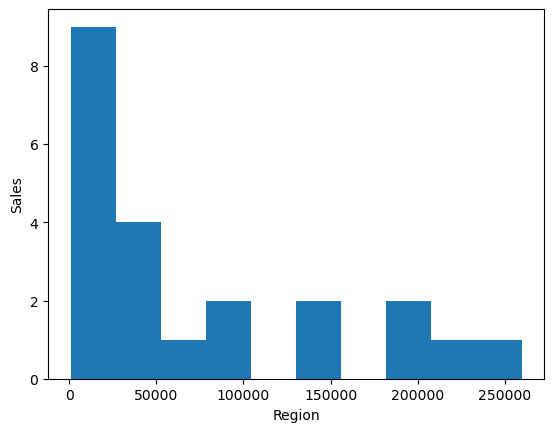

In [107]:
df_by_Region = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

By_Region_plot = df_by_Region.plot(kind='hist')
# By_Region_plott.set_yscale('log')
By_Region_plot.set_xlabel('Region')
By_Region_plot.set_ylabel('Sales')
## WRONG

Text(0.5, 1.0, 'Sales by Region')

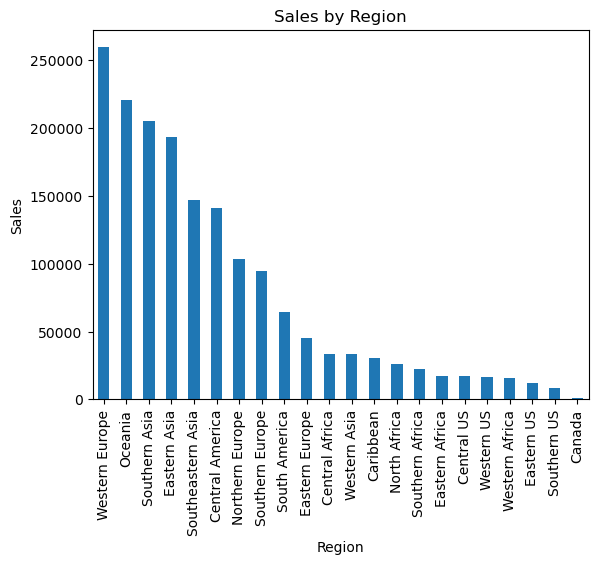

In [108]:
# Plot Sales by Region
df_by_Region = (
    df.groupby('Region')['Sales']
      .sum()
      .sort_values(ascending=False)
)

By_Region_plot = df_by_Region.plot(kind='bar')

By_Region_plot.set_xlabel('Region')
By_Region_plot.set_ylabel('Sales')
By_Region_plot.set_title('Sales by Region')


Text(0.5, 1.0, 'Sales by Segment')

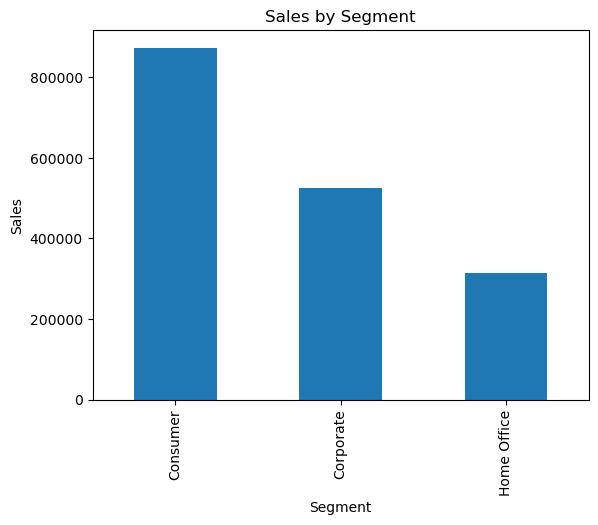

In [109]:
# Plot Sales by Segment
df_by_Segment = (
    df.groupby('Segment')['Sales']
      .sum()
      .sort_values(ascending=False)
)

By_Segment_plot = df_by_Segment.plot(kind='bar')

By_Segment_plot.set_xlabel('Segment')
By_Segment_plot.set_ylabel('Sales')
By_Segment_plot.set_title('Sales by Segment')

Text(0.5, 1.0, 'Sales by Market')

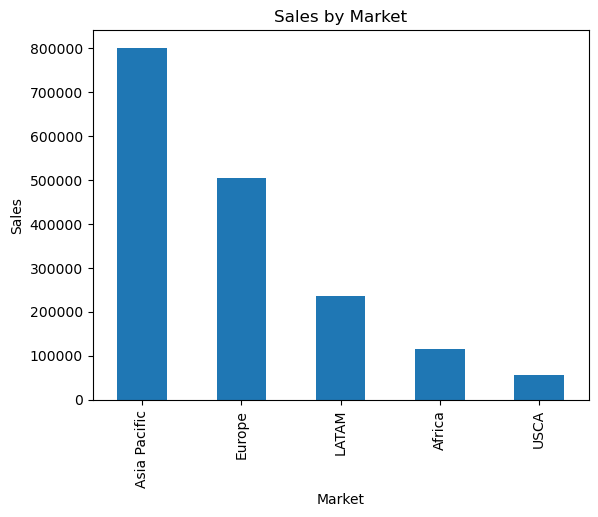

In [110]:
# Plot Sales by Market
df_by_Market = (
    df.groupby('Market')['Sales']
      .sum()
      .sort_values(ascending=False)
)

By_Market_plot = df_by_Market.plot(kind='bar')

By_Market_plot.set_xlabel('Market')
By_Market_plot.set_ylabel('Sales')
By_Market_plot.set_title('Sales by Market')

Text(0.5, 1.0, 'Sales by Category')

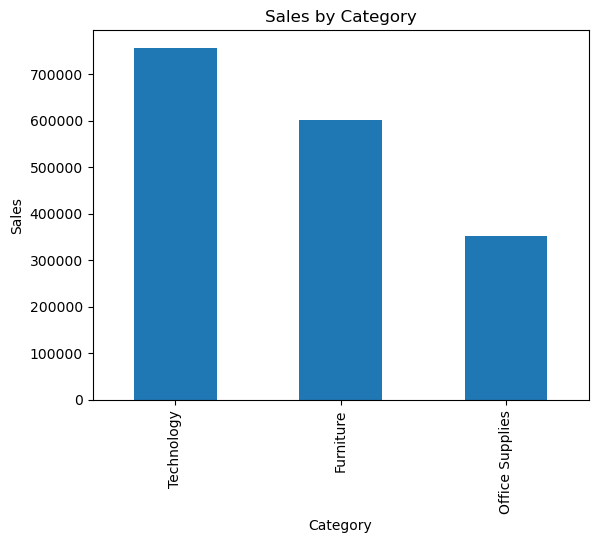

In [111]:
# Plot Sales by Category
df_by_Category = (
    df.groupby('Category')['Sales']
      .sum()
      .sort_values(ascending=False)
)

By_Category_plot = df_by_Category.plot(kind='bar')

By_Category_plot.set_xlabel('Category')
By_Category_plot.set_ylabel('Sales')
By_Category_plot.set_title('Sales by Category')

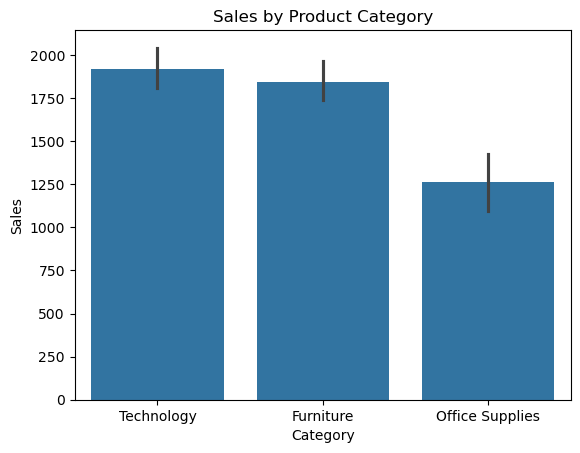

In [112]:
# Sales by Product Category
sns.barplot(x='Category', y='Sales', data=df)
plt.title('Sales by Product Category')
plt.show()
# Issue is that groupby is an agregating function which increases the value of the Sales by Catagory
# Hence the sns and plt plot have different max values

Text(0.5, 1.0, 'Sales by Ship Mode')

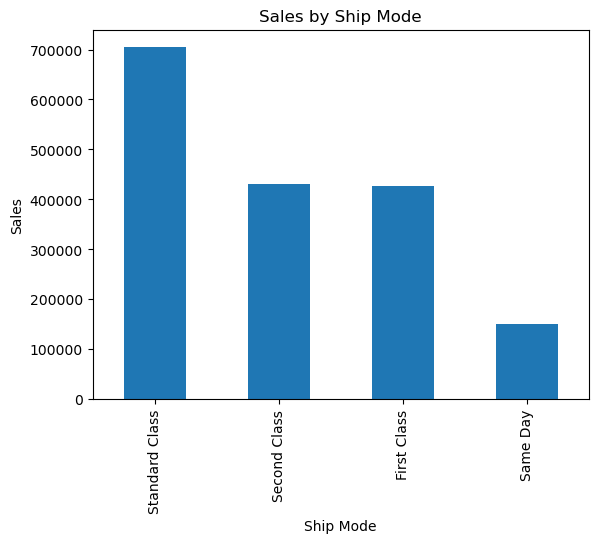

In [113]:
# Plot Sales by Ship Mode
df_by_Ship_Mode = (
    df.groupby('Ship Mode')['Sales']
      .sum()
      .sort_values(ascending=False)
)

By_Ship_Mode_plot = df_by_Ship_Mode.plot(kind='bar')

By_Ship_Mode_plot.set_xlabel('Ship Mode')
By_Ship_Mode_plot.set_ylabel('Sales')
By_Ship_Mode_plot.set_title('Sales by Ship Mode')

Text(0.5, 1.0, 'Sales by Order Priority')

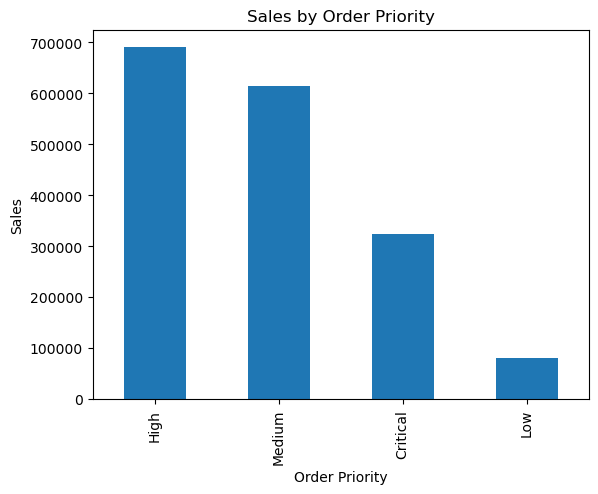

In [114]:
# Plot Sales by Order Priority
df_by_Order_Priority = (
    df.groupby('Order Priority')['Sales']
      .sum()
      .sort_values(ascending=False)
)

By_Order_Priority_plot = df_by_Order_Priority.plot(kind='bar')

By_Order_Priority_plot.set_xlabel('Order Priority')
By_Order_Priority_plot.set_ylabel('Sales')
By_Order_Priority_plot.set_title('Sales by Order Priority')

In [115]:
## Basic descriptive statistics
# These give a quick sense of scale and distribution.
df[['Sales', 'Profit']].describe()

,Sales,Profit
count,1000.000000,1000.000000
mean,1710.971470,288.920440
std,1259.239238,574.504782
min,1.910000,-3059.820000
25%,826.907500,10.037500
50%,1585.115000,190.685000
75%,2477.812500,518.872500
max,9892.740000,4946.370000


In [116]:
## Check correlation
# A simple but powerful indicator of linear relationship.
df[['Sales', 'Profit']].corr()

,Sales,Profit
Sales,1.000000,0.533676
Profit,0.533676,1.000000


In [117]:
category_corr = (
    df.groupby('Category')[['Sales', 'Profit']]
      .corr()
      .unstack()
      .iloc[:, 1]   # extract the Sales–Profit correlation
)

category_corr


Category
Furniture          0.390817
Office Supplies    0.645094
Technology         0.535162
Name: (Sales, Profit), dtype: float64

In [118]:
# 
correlation = df['Sales'].corr(df['Profit'])
print(correlation )

0.5336756228051001


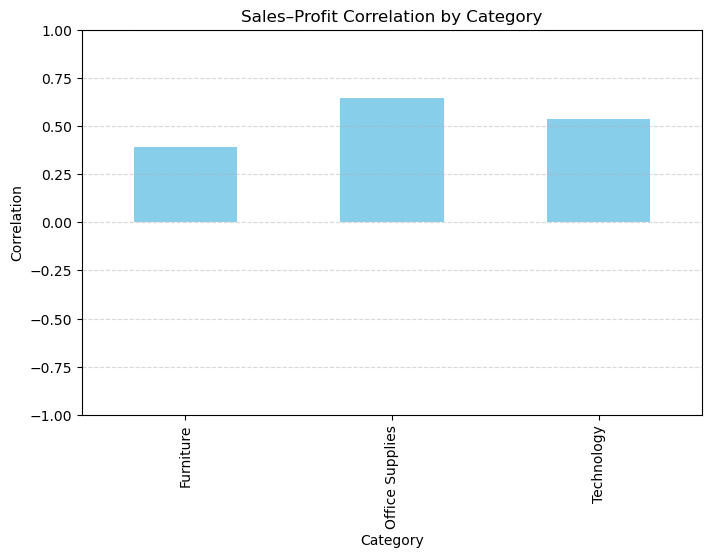

In [119]:
# Bar chart of correlations

plt.figure(figsize=(8,5))
category_corr.plot(kind='bar', color='skyblue')
plt.title("Sales–Profit Correlation by Category")
plt.ylabel("Correlation")
plt.ylim(-1, 1)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


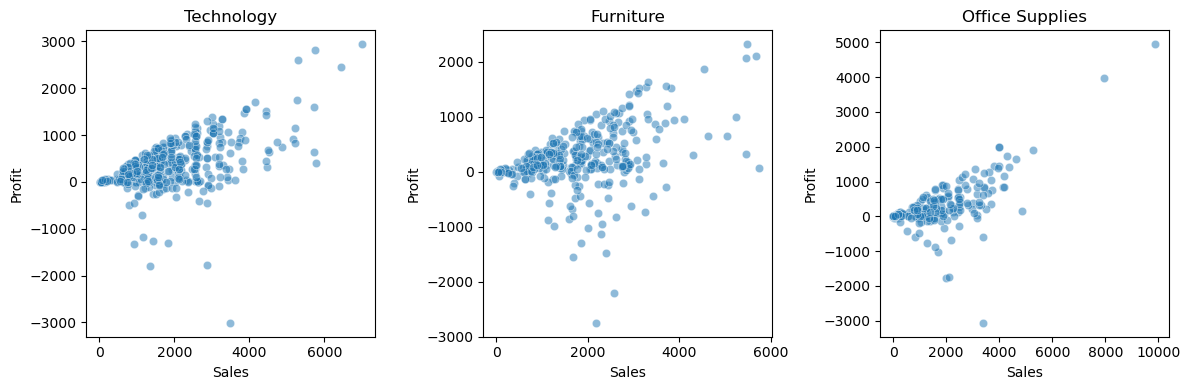

In [120]:
# Scatter plots by category

plt.figure(figsize=(12,4))

for i, cat in enumerate(df['Category'].unique()):
    plt.subplot(1, 3, i+1)
    sns.scatterplot(
        data=df[df['Category'] == cat],
        x='Sales', y='Profit', alpha=0.5
    )
    plt.title(cat)
    plt.tight_layout()


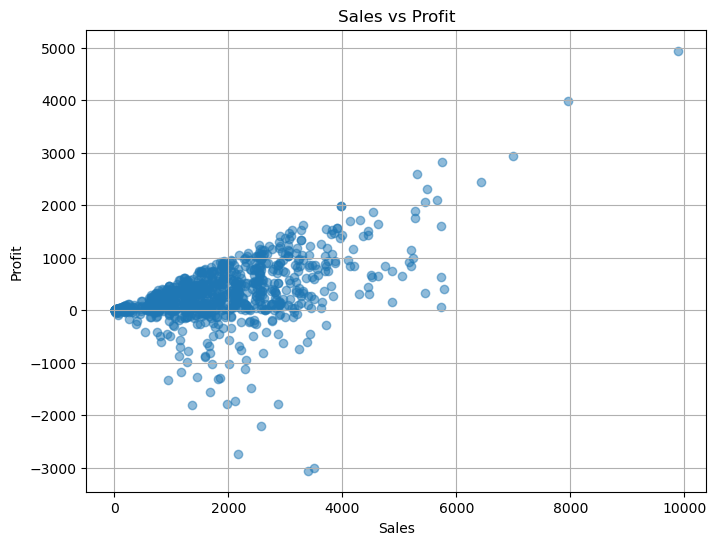

In [121]:
## 4. Scatter plot: Sales vs. Profit
# This is the most direct way to visualize the relationship.

plt.figure(figsize=(8,6))
plt.scatter(df['Sales'], df['Profit'], alpha=0.5)
plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.grid(True)
plt.show()


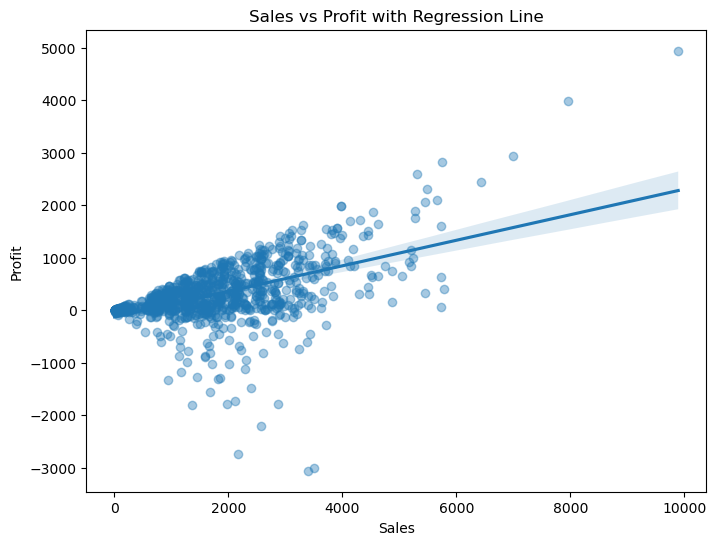

In [ ]:
## 5. Add a regression line (optional but insightful)

plt.figure(figsize=(8,6))
sns.regplot(x='Sales', y='Profit', data=df, scatter_kws={'alpha':0.4})
plt.title("Sales vs Profit with Regression Line")
plt.savefig("images/Sales-vs-Profit_with_Regression_Line.png")  # Save the figure
plt.show()


In [123]:
## 6. Profitability by category or segment
# Sometimes the relationship becomes clearer when grouped.

### Profit margin by category

df['Profit Margin'] = df['Profit'] / df['Sales']

df.groupby('Category')['Profit Margin'].mean().sort_values()


Category
Furniture          0.117906
Office Supplies    0.151333
Technology         0.179304
Name: Profit Margin, dtype: float64

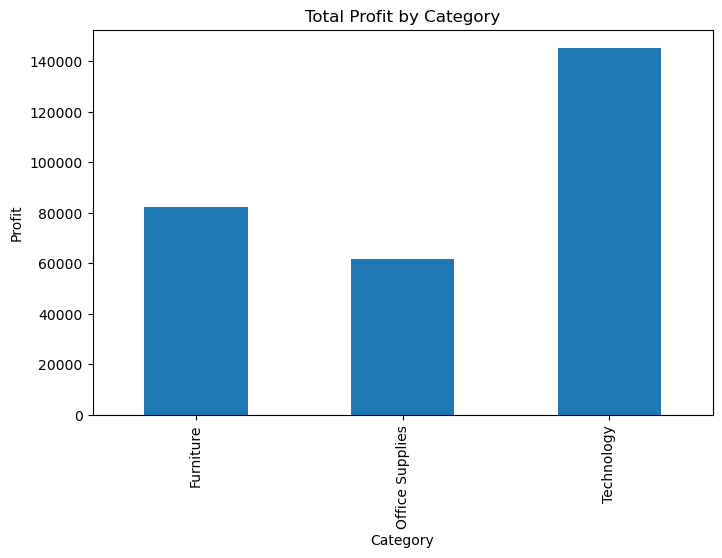

In [ ]:
### Bar chart
df.groupby('Category')['Profit'].sum().plot(kind='bar', figsize=(8,5))
plt.title("Total Profit by Category")
plt.ylabel("Profit")
plt.savefig("images/Total_Profit_by_Category.png")  # Save the figure
plt.show()

In [125]:
## Identify loss‑making sales
# Useful for spotting outliers.

losses = df[df['Profit'] < 0]
losses[['Sales', 'Profit']].head()

,Sales,Profit
1,3709.40,-288.77
3,2892.51,-96.54
16,12.62,-2.52
30,1696.64,-148.46
40,3200.60,-77.20


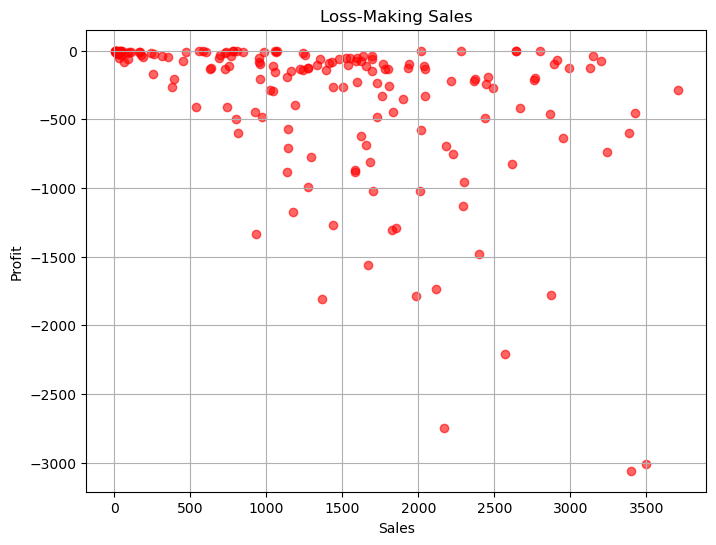

In [126]:
# Plot them:

plt.figure(figsize=(8,6))
plt.scatter(losses['Sales'], losses['Profit'], color='red', alpha=0.6)
plt.title("Loss-Making Sales")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.grid(True)
plt.savefig("Loss-Making_Sales.png")  # Save the figure
plt.show()

In [127]:
# 7. Data Visualization

#    Create a bar chart of sales by product category
#    Plot a line graph of monthly sales over time
#    Generate a scatter plot of sales vs. profit
#    Produce a heatmap of sales by region and product category

In [128]:
### Bar chart

Text(0.5, 1.0, 'Sales by Category')

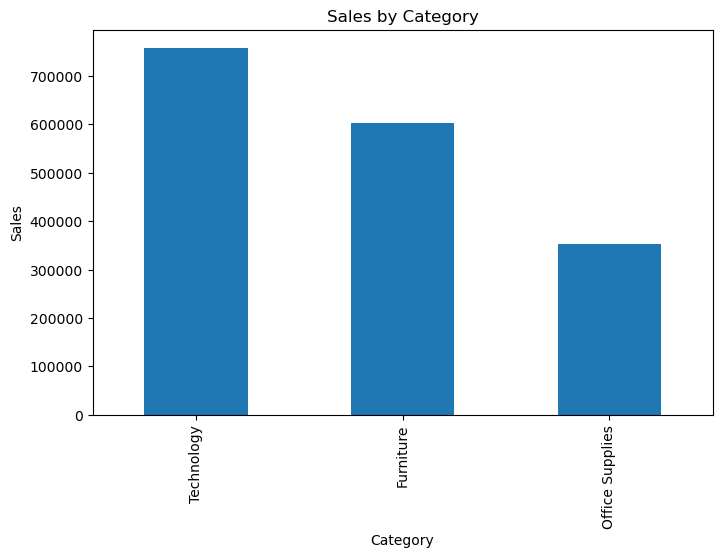

In [129]:
# Create a bar chart of sales by product category
# Plot Sales by Category
df_by_Category = (
    df.groupby('Category')['Sales']
      .sum()
      .sort_values(ascending=False)
)

By_Category_plot = df_by_Category.plot(kind='bar', figsize=(8,5))

By_Category_plot.set_xlabel('Category')
By_Category_plot.set_ylabel('Sales')
By_Category_plot.set_title('Sales by Category')

In [130]:
# Ensure Order Date is a datetime type
# df['Order Date'] = pd.to_datetime(df['Order Date'])

# Sort by date so the line moves forward in time
df = df.sort_values('Order Date')

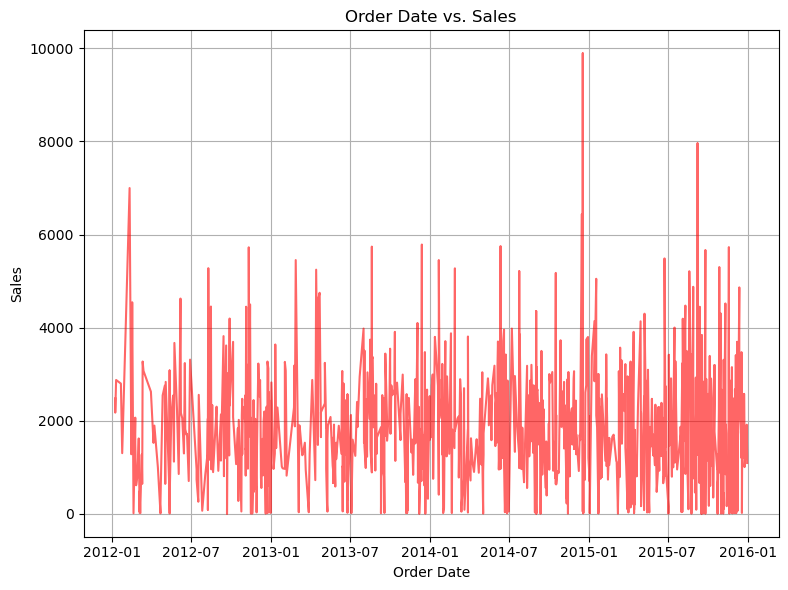

In [131]:
# Plot a line graph of monthly sales over time
plt.figure(figsize=(8,6))
plt.plot(df['Order Date'], df['Sales'], color='red', alpha=0.6)
plt.title("Order Date vs. Sales")
plt.xlabel("Order Date")
plt.ylabel("Sales")
plt.grid(True)
plt.tight_layout()
plt.savefig("Order_Date-vs-Sales.png")  # Save the figure
plt.show()

In [132]:
# IS
# Add month column to dataframe
df['Month'] = df['Order Date'].dt.to_period('M')
df['Month'].head()

328    2012-01
562    2012-01
39     2012-01
399    2012-01
764    2012-01
Name: Month, dtype: period[M]

In [133]:
# IS
monthly_sales = df.groupby('Month')['Sales'].sum()
monthly_sales

Month
2012-01    11627.23
2012-02    20635.28
2012-03    13516.89
2012-04     7222.25
2012-05    21908.53
2012-06    23481.90
2012-07     4574.81
2012-08    29970.83
2012-09    31389.30
2012-10    23580.75
2012-11    58896.74
2012-12    47025.31
2013-01    14402.93
2013-02    22164.25
2013-03    10405.16
2013-04    25287.97
2013-05    30694.90
2013-06    31585.12
2013-07    13548.22
2013-08    66614.54
2013-09    25822.39
2013-10    37641.53
2013-11    25235.48
2013-12    49167.84
2014-01    42462.14
2014-02    30425.23
2014-03    21085.80
2014-04    13763.79
2014-05    34196.44
2014-06    77680.63
2014-07    25321.53
2014-08    30584.96
2014-09    36137.31
2014-10    43070.62
2014-11    42334.92
2014-12    59780.92
2015-01    42446.84
2015-02    20866.47
2015-03    38056.77
2015-04    40013.98
2015-05    40409.85
2015-06    52355.51
2015-07    39119.16
2015-08    63609.94
2015-09    84348.76
2015-10    52017.73
2015-11    65013.87
2015-12    69468.15
Freq: M, Name: Sales, dtype: float

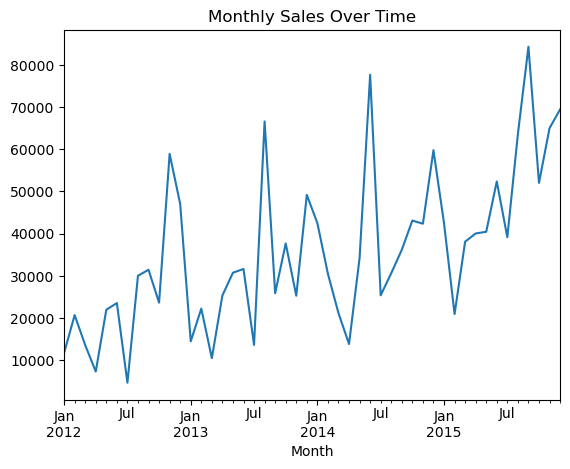

In [ ]:
# IS
# Ensure the index is in datetime format for plotting
# monthly_sales.index = monthly_sales.index.to_timestamp()  # WHY ??

# Plot Monthly Sales over timme
monthly_sales.plot(kind='line')
plt.title('Monthly Sales Over Time')
plt.savefig("images/Monthly_Sales_Over_Time.png")  # Save the figure
plt.show()

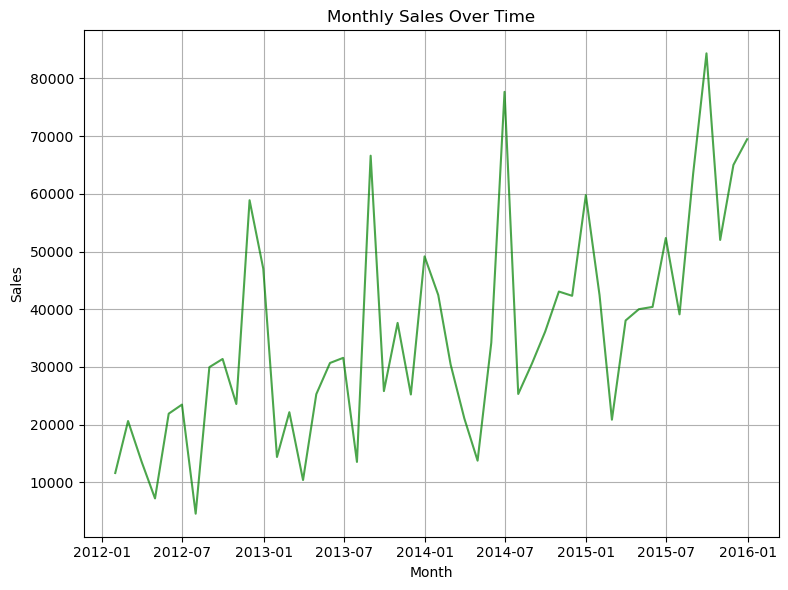

In [ ]:
# 
# df['Order Date'] = pd.to_datetime(df['Order Date'])

monthly = df.resample('ME', on='Order Date')['Sales'].sum()

plt.figure(figsize=(8,6))
plt.plot(monthly.index, monthly.values, color='green', alpha=0.7)

plt.title("Monthly Sales Over Time")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.grid(True)
plt.tight_layout()
plt.savefig("images/Monthly_Sales_Over_Time2.png")  # Save the figure
plt.show()


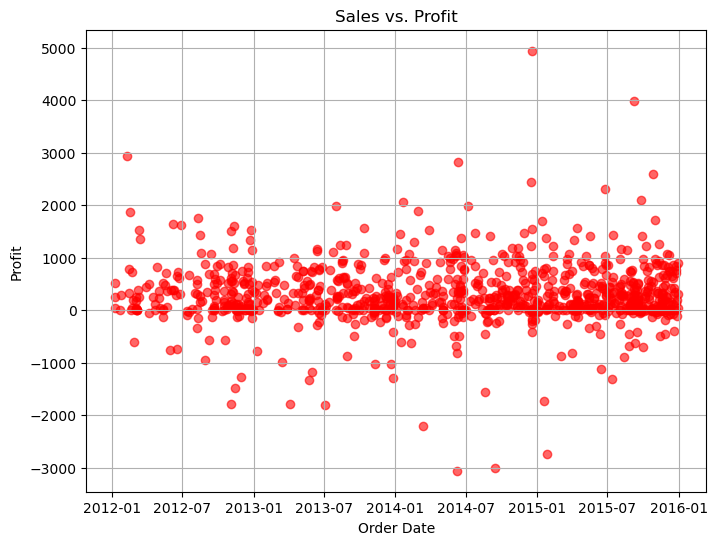

In [ ]:
#    Generate a scatter plot of sales vs. profit
plt.figure(figsize=(8,6))
plt.scatter(df['Order Date'], df['Profit'], color='red', alpha=0.6)
plt.title("Sales vs. Profit")
plt.xlabel("Order Date")
plt.ylabel("Profit")
plt.grid(True)
plt.savefig("images/Sales-vs-Profit.png")  # Save the figure
plt.show()

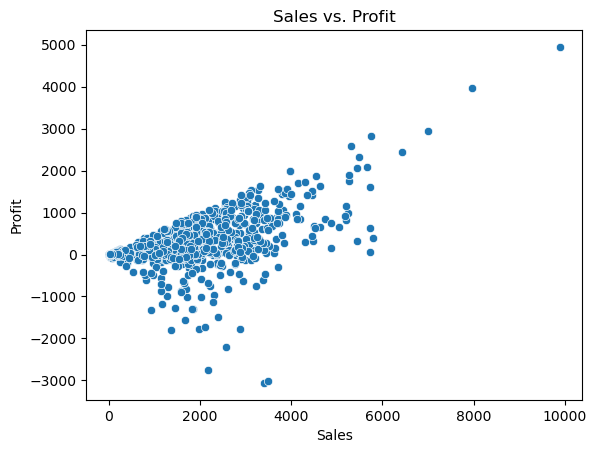

In [ ]:
# IS
sns.scatterplot(x='Sales', y='Profit', data=df)
plt.title('Sales vs. Profit')
plt.savefig("images/Scatter-plot_Sales-vs-Profit.png")  # Save the figure

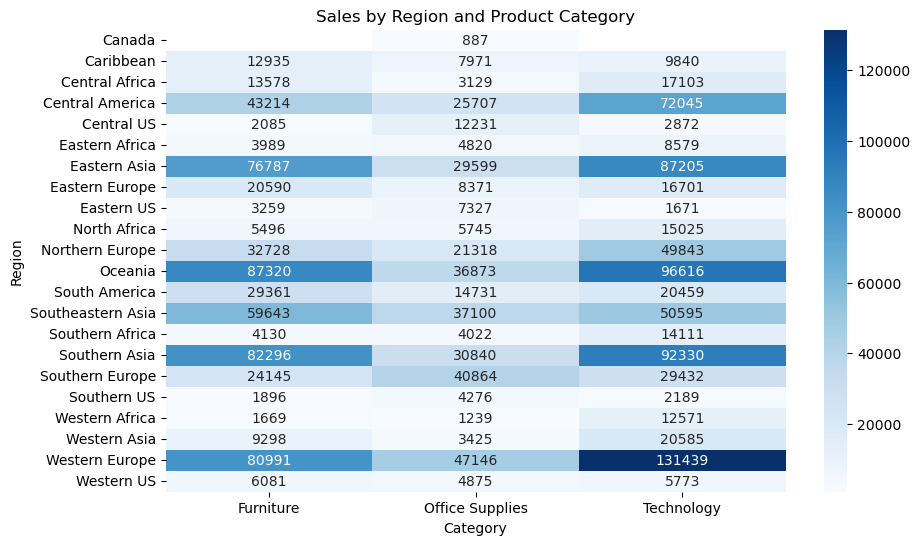

In [ ]:
# Produce a heatmap of sales by region and product category
# Example: df is your DataFrame with columns: Region, Category, Sales
pivot = df.pivot_table(
    index="Region",
    columns="Category",
    values="Sales",
    aggfunc="sum"
)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="Blues")
plt.title("Sales by Region and Product Category")
plt.savefig("images/Sales_by_Region_and_Product_Category1.png")  # Save the figure
plt.show()


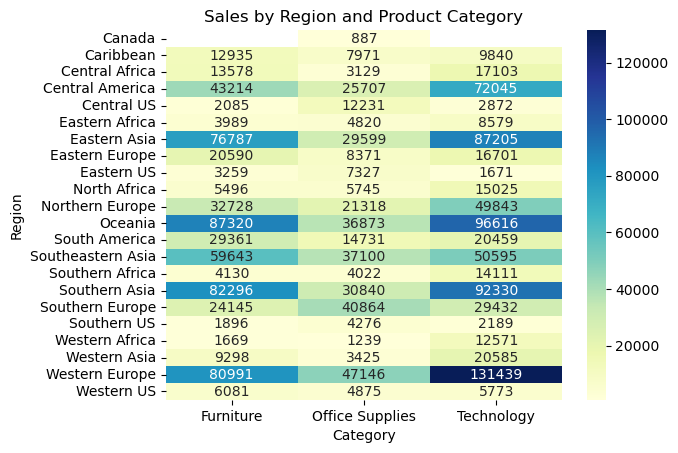

In [ ]:
# IS
# heatmap of sales by region and product category

# Pivot table for Sales by Region and Category
pivot_table = df.pivot_table(values='Sales', index='Region', columns='Category', aggfunc='sum')

sns.heatmap(pivot_table, annot=True, fmt='.0f', cmap='YlGnBu')
plt.title('Sales by Region and Product Category')
plt.savefig("images/Sales_by_Region_and_Product_Category2.png")  # Save the figure

In [140]:
# 8. Derive Insights
#    Based on your analysis and visualizations, list 3-5 key insights about GlobalMart's sales performance


In [141]:
# 9. Bonus Challenge
#    Perform a simple time series analysis to identify any sales trends or seasonality


In [142]:
# 📈 Time Series Analysis of Sales  
### Using your DataFrame (1,000 rows, daily order dates)

## 1. **Prepare the time series**
# You want monthly granularity because daily sales are usually too noisy.


# df['Order Date'] = pd.to_datetime(df['Order Date'])

monthly_sales = (
    df.resample('ME', on='Order Date')['Sales']
      .sum()
      .to_frame(name='Sales')
)


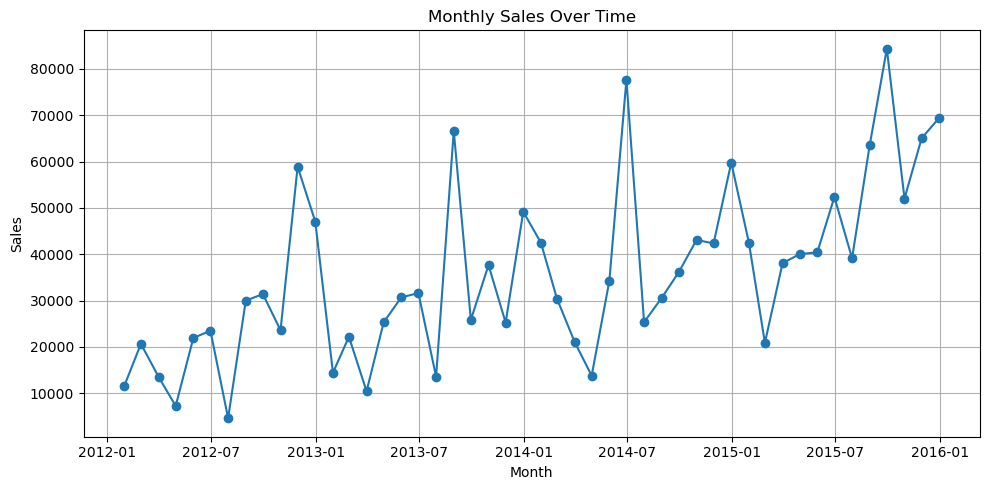

In [ ]:
## 2. **Plot the monthly sales trend**
# This gives you the first visual sense of upward/downward movement.

plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index, monthly_sales['Sales'], marker='o')
plt.title("Monthly Sales Over Time")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.grid(True)
plt.tight_layout()
plt.savefig("images/Plot_Monthly_Sales_Over_Time.png")  # Save the figure
plt.show()



**What to look for:**  
- A steady upward slope → long‑term growth  
- A downward slope → contraction  
- Repeating peaks/dips → seasonality  

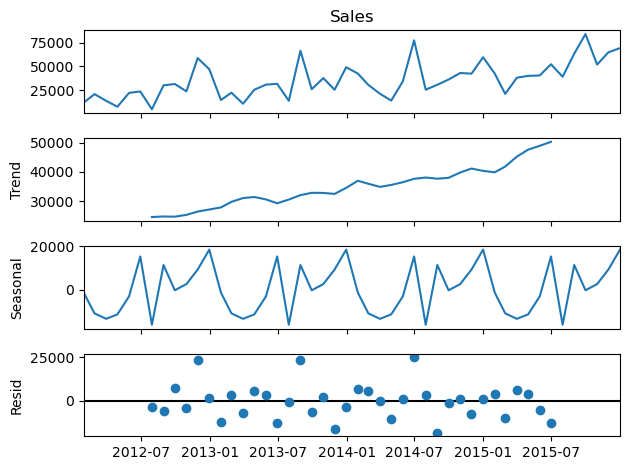

In [ ]:
##  **Decompose the time series (trend + seasonality + residuals)**  
# This is the quickest way to *see* seasonality.

from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(monthly_sales['Sales'], model='additive', period=12)
decomp.plot()
plt.tight_layout()
plt.savefig("images/Seasonal_decomposition.png")  # Save the figure
plt.show()


**Interpretation guide:**  
- **Trend component:** smooth long‑term direction  
- **Seasonal component:** repeating yearly patterns  
- **Residual:** noise or irregular events  

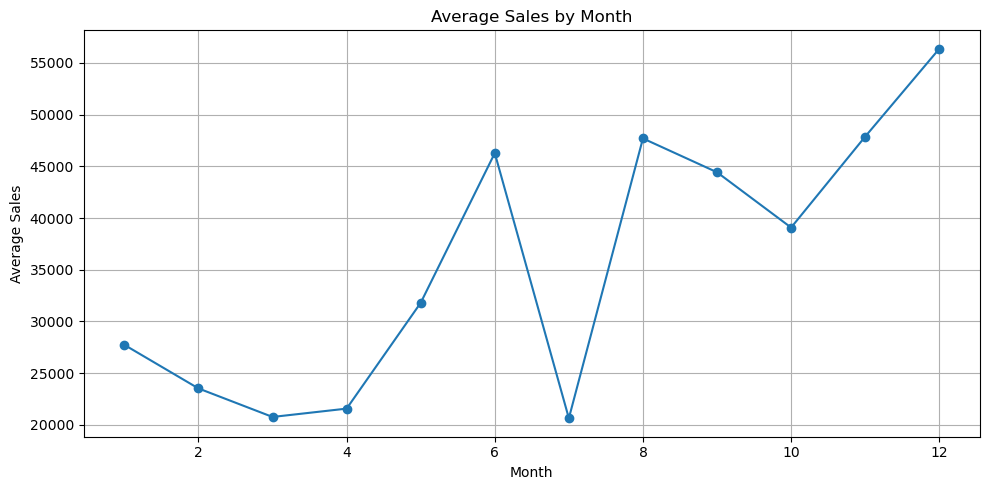

In [ ]:
## 4. **Check for month‑of‑year seasonality**
# This helps confirm whether certain months consistently outperform others.

monthly_sales['Month'] = monthly_sales.index.month

monthly_avg = monthly_sales.groupby('Month')['Sales'].mean()

plt.figure(figsize=(10,5))
plt.plot(monthly_avg.index, monthly_avg.values, marker='o')
plt.title("Average Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.grid(True)
plt.tight_layout()
plt.savefig("images/Average_Sales_by_Month.png")  # Save the figure
plt.show()

**What you might find:**  
- Peaks around November/December → holiday season  
- Dips in summer → common in B2B markets  
- Strong Q1 → new‑year procurement cycles  

### **Trend**
- A gradual upward trend if the business is growing  
- Occasional dips tied to economic cycles or promotions ending  

### **Seasonality**
- **Holiday spikes** (Nov–Dec)  
- **Back‑to‑school bumps** (Aug–Sep)  
- **Slow periods** in early Q2  

Your decomposition plot will make these patterns obvious.

### References

In [146]:
# 1 
# Source - https://stackoverflow.com/a/49189503
# Posted by YOLO, modified by community. See post 'Timeline' for change history
# Retrieved 2026-02-10, License - CC BY-SA 4.0

# pd.set_option('display.max_columns', None)
# pd.set_option('display.max_rows', None)

# 2 
# Bing CoPilot 10/02/2026

